In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1. 文件路径
# ======================
csv_path = "sitesresults20251207.csv"  # 换成你的实际文件名

# ======================
# 2. GB 平面参数：Ax + By + Cz + D = 0
#    把下面这四个值改成你自己的 A, B, C, D
# ======================
# double GB_A = -0.5488;      // 假设 A=0，平面垂直于 XZ 平面
#     double GB_B = -3.4971;      // B=1.0, C=1.0, D=-box_size/2.0 * B - box_size/2.0 * C 
#     double GB_C = -1.0;      // 45度倾斜
#     double GB_D = -0.5488*0.002-3.4971*0.0005-0.002+0.0076; 
A = -0.5488;
B = -3.4971
C = -1.0
D = -0.5488*0.002-3.4971*0.0005-0.002+0.0076  

In [9]:
# ======================
# 1. 读入数据
# ======================
# 如果是空格/Tab 分隔、无表头：
df = pd.read_csv(csv_path, header=None, names=["elem", "x", "y", "z"])

df.head()

,elem,x,y,z
0,Si,0.000623,0.000629,0.000229
1,Si,0.000784,0.000852,0.000960
2,Si,0.000328,0.000829,0.000985
3,Si,0.000147,0.000571,0.000691
4,Si,0.000642,0.000486,0.000690


In [10]:
# ======================
# 2. 计算到 GB 平面的距离
# ======================
norm = np.sqrt(A**2 + B**2 + C**2)
df["dist_signed"] = (A*df["x"] + B*df["y"] + C*df["z"] + D) / norm
df["dist_abs"] = df["dist_signed"].abs()

# 分别取出 Si 和 Cr
df_si = df[df["elem"] == "Si"].copy()
df_cr = df[df["elem"] == "Cr"].copy()

print("Si count:", len(df_si))
print("Cr count:", len(df_cr))
df_si.head()

Si count: 1000
Cr count: 1000


,elem,x,y,z,dist_signed,dist_abs
0,Si,0.000623,0.000629,0.000229,-0.000005,0.000005
1,Si,0.000784,0.000852,0.000960,-0.000439,0.000439
2,Si,0.000328,0.000829,0.000985,-0.000356,0.000356
3,Si,0.000147,0.000571,0.000691,-0.000004,0.000004
4,Si,0.000642,0.000486,0.000690,0.000003,0.000003


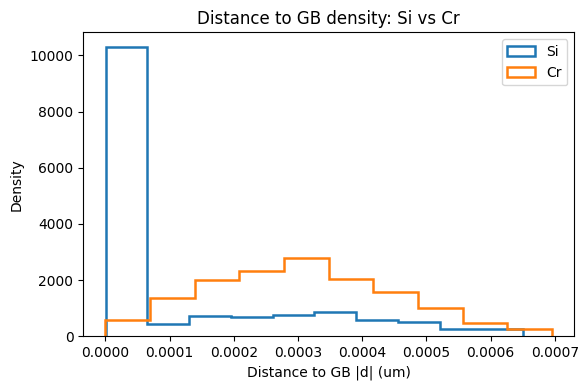

In [11]:
# ======================
# 3. 绘制 Si / Cr 到 GB 的距离密度分布
# ======================

plt.figure(figsize=(6, 4))

# 直方图参数
bins = 10   # 分箱数，可以根据数据量调整

plt.hist(df_si["dist_abs"], bins=bins, density=True,
         histtype="step", linewidth=1.8, label="Si")
plt.hist(df_cr["dist_abs"], bins=bins, density=True,
         histtype="step", linewidth=1.8, label="Cr")

plt.xlabel("Distance to GB |d| (um)")
plt.ylabel("Density")
plt.title("Distance to GB density: Si vs Cr")
plt.legend()
plt.tight_layout()
plt.show()

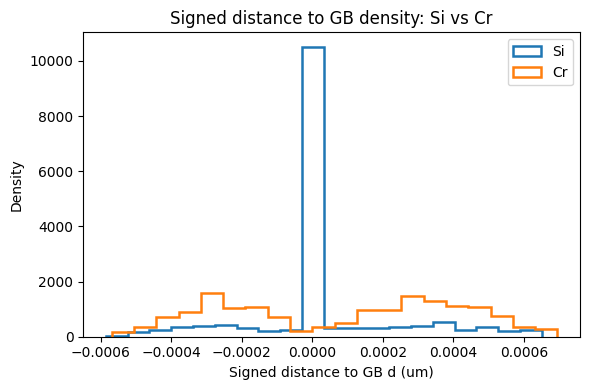

In [12]:
plt.figure(figsize=(6, 4))

bins = 20

plt.hist(df_si["dist_signed"], bins=bins, density=True,
         histtype="step", linewidth=1.8, label="Si")
plt.hist(df_cr["dist_signed"], bins=bins, density=True,
         histtype="step", linewidth=1.8, label="Cr")

plt.xlabel("Signed distance to GB d (um)")
plt.ylabel("Density")
plt.title("Signed distance to GB density: Si vs Cr")
plt.legend()
plt.tight_layout()
plt.show()

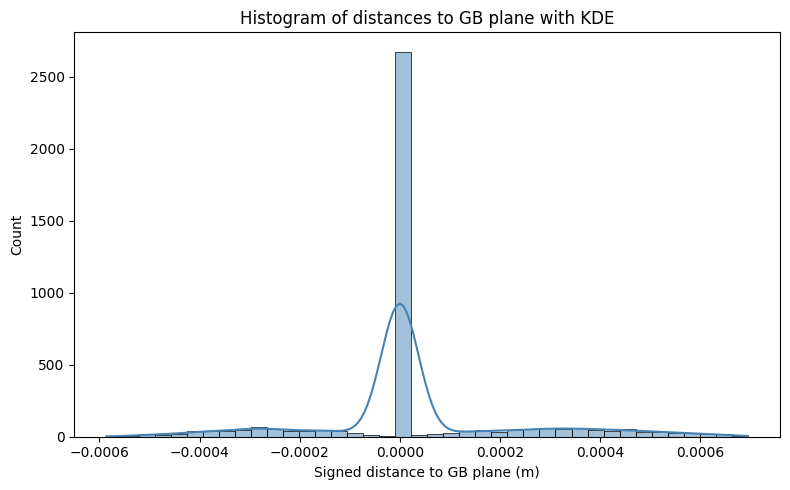

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 你前面计算好的 signed distance:
# df["dist_signed"]

plt.figure(figsize=(8,5))

sns.histplot(
    df["dist_signed"],
    bins=40,
    kde=True,            # 自动叠加平滑曲线（KDE）
    stat="count",        # y 轴使用“计数”
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Signed distance to GB plane (m)")
plt.ylabel("Count")
plt.title("Histogram of distances to GB plane with KDE")

plt.tight_layout()
plt.show()

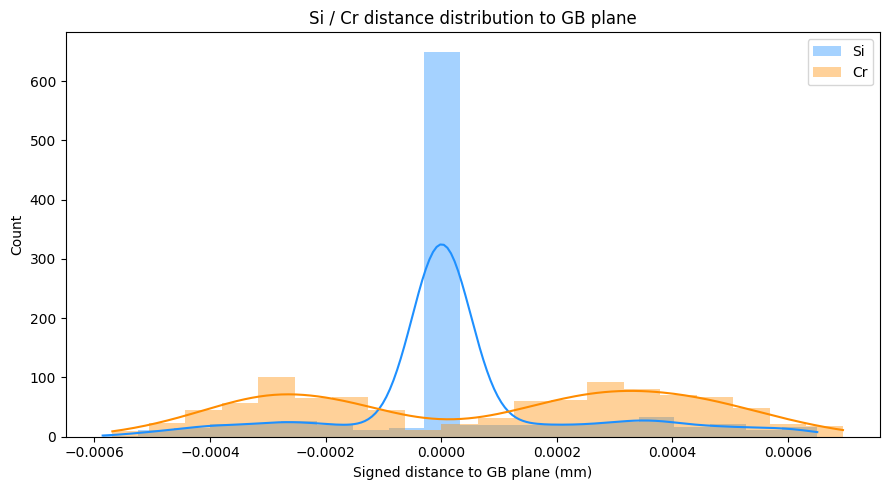

In [14]:
plt.figure(figsize=(9,5))

# ----- Si -----
sns.histplot(
    df_si["dist_signed"], 
    bins=20,
    kde=True,
    stat="count",
    color="dodgerblue",
    label="Si",
    alpha=0.4,
    edgecolor=None
)

# ----- Cr -----
sns.histplot(
    df_cr["dist_signed"], 
    bins=20,
    kde=True,
    stat="count",
    color="darkorange",
    label="Cr",
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("Signed distance to GB plane (mm)")
plt.ylabel("Count")
plt.title("Si / Cr distance distribution to GB plane")
plt.legend()

plt.tight_layout()
plt.show()